In [1]:
!pip -q install ultralytics roboflow tensorboard opencv-python plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.6 MB/s eta 0:00:0000:01


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

BEST_DIR = "/content/drive/MyDrive/taller alfredo"
os.makedirs(BEST_DIR, exist_ok=True)

print("✅ Carpeta creada/verificada:", BEST_DIR)

✅ Carpeta creada/verificada: /content/drive/MyDrive/taller alfredo


In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")
project = rf.workspace("cicatriz").project("ppe-factory-bmdcj-alnpk")
version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-factory-1 in yolov8:: 100%|██████████| 21608/21608 [00:03<00:00, 6492.13it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
import os

BASE = dataset.location  # ruta automática de Roboflow
print("📁 Dataset en:", BASE)

for split in ["train", "valid", "test"]:
    for sub in ["images", "labels"]:
        path = os.path.join(BASE, split, sub)
        if os.path.exists(path):
            print(f"✅ {path} -> {len(os.listdir(path))} archivos")
        else:
            print(f"⚠️ Falta: {path}")

📁 Dataset en: /content/ppe-factory-1
✅ /content/ppe-factory-1/train/images -> 9770 archivos
✅ /content/ppe-factory-1/train/labels -> 9770 archivos
✅ /content/ppe-factory-1/valid/images -> 742 archivos
✅ /content/ppe-factory-1/valid/labels -> 742 archivos
✅ /content/ppe-factory-1/test/images -> 286 archivos
✅ /content/ppe-factory-1/test/labels -> 286 archivos


In [7]:
from ultralytics import YOLO

# Cargar modelo base
model = YOLO("yolov8n.pt")

# Entrenar
results = model.train(
    data=os.path.join(BASE, "data.yaml"),
    epochs=10,
    imgsz=640,
    batch=16,
    workers=1,
    project=BEST_DIR,          # 📁 Drive
    name="ppe_factory_v1",     # subcarpeta
    exist_ok=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe-factory-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_factory_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [8]:
best_path = os.path.join(
    BEST_DIR,
    "ppe_factory_v1",
    "weights",
    "best.pt"
)

print("✅ best.pt encontrado:", os.path.exists(best_path))
print("📍 Ruta:", best_path)

✅ best.pt encontrado: True
📍 Ruta: /content/drive/MyDrive/taller alfredo/ppe_factory_v1/weights/best.pt



image 1/1 /content/ppe-factory-1/test/images/IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg: 640x640 10 helmets, 9 persons, 7 vests, 7.6ms
Speed: 3.8ms preprocess, 7.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

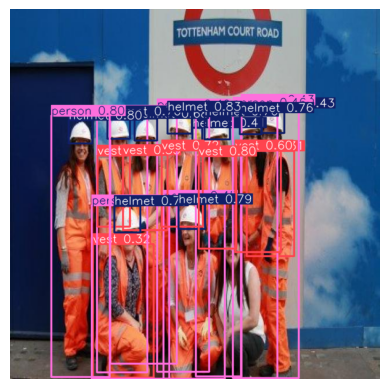

In [9]:
import cv2
from matplotlib import pyplot as plt

# Cargar modelo entrenado
model = YOLO(best_path)

# Imagen de prueba (ajusta si es necesario)
test_image = os.path.join(BASE, "test/images")
img_name = os.listdir(test_image)[0]
image_path = os.path.join(test_image, img_name)

# Predicción
results = model.predict(source=image_path, imgsz=640, save=False)

# Mostrar resultado
annotated = results[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
